# Measures of Shape (Skewness & Kurtosis)

In [127]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statistics as st
import seaborn as sns

In [104]:

np.random.seed(42)

n = 200

Cus = pd.DataFrame({

    "Customer_ID": range(1001,1001+n),

    "Age": np.random.randint(21,61,n),

    "Monthly_Income": np.random.randint(25000,150000,n),

    "Account_Balance": np.random.randint(5000,600000,n),

    "Loan_Amount": np.random.randint(0,1500000,n),

    "Credit_Score": np.random.randint(300,900,n),

    "City": np.random.choice([
        "Mumbai",
        "Pune",
        "Delhi",
        "Bengaluru",
        "Hyderabad",
        "Chennai"
    ],n)

})

Cus.head()

,Customer_ID,Age,Monthly_Income,Account_Balance,Loan_Amount,Credit_Score,City
0,1001,59,67107,447905,612380,437,Pune
1,1002,49,111202,240362,1365413,483,Chennai
2,1003,35,134893,449209,1337682,700,Hyderabad
3,1004,28,76663,558880,1076871,629,Delhi
4,1005,41,40708,224963,1062383,807,Delhi


In [4]:
Cus.shape

(200, 7)

In [5]:
Cus.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Customer_ID      200 non-null    int64 
 1   Age              200 non-null    int32 
 2   Monthly_Income   200 non-null    int32 
 3   Account_Balance  200 non-null    int32 
 4   Loan_Amount      200 non-null    int32 
 5   Credit_Score     200 non-null    int32 
 6   City             200 non-null    object
dtypes: int32(5), int64(1), object(1)
memory usage: 7.2+ KB


In [6]:
Cus.describe()

,Customer_ID,Age,Monthly_Income,Account_Balance,Loan_Amount,Credit_Score
count,200.000000,200.000000,200.000000,200.000000,2.000000e+02,200.00000
mean,1100.500000,40.575000,85081.680000,283265.640000,7.606248e+05,582.85000
std,57.879185,12.026954,37744.390904,173632.289684,4.276891e+05,181.61901
min,1001.000000,21.000000,25301.000000,8051.000000,4.040000e+02,300.00000
25%,1050.750000,29.000000,54716.000000,134624.500000,4.151605e+05,417.00000
50%,1100.500000,42.000000,81370.500000,255080.500000,7.521345e+05,580.50000
75%,1150.250000,52.000000,119299.250000,443834.000000,1.139610e+06,740.50000
max,1200.000000,60.000000,149249.000000,599319.000000,1.498189e+06,895.00000


In [7]:
Cus.columns

Index(['Customer_ID', 'Age', 'Monthly_Income', 'Account_Balance',
       'Loan_Amount', 'Credit_Score', 'City'],
      dtype='object')

In [8]:
Cus.isnull().sum()

Customer_ID        0
Age                0
Monthly_Income     0
Account_Balance    0
Loan_Amount        0
Credit_Score       0
City               0
dtype: int64

In [10]:
Cus.duplicated().sum()

np.int64(0)

In [11]:
mean = Cus["Loan_Amount"].mean()

median = Cus["Loan_Amount"].median()

mode = Cus["Loan_Amount"].mode()[0]

print(f"Mean : {mean:.2f}")

print(f"Median : {median:.2f}")

print(f"Mode : {mode:.2f}")

Mean : 760624.79
Median : 752134.50
Mode : 404.00


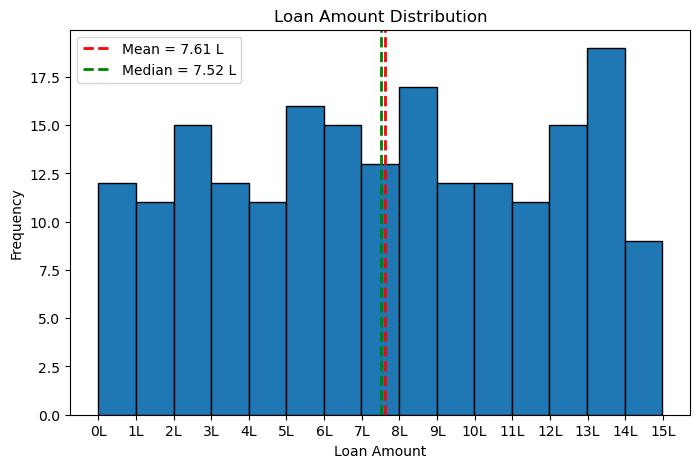

In [30]:
plt.figure(figsize=(8,5))

plt.hist(
    Cus["Loan_Amount"],
    bins=15,
    edgecolor="black"
)

plt.axvline(mean, color='red', linestyle='--', linewidth=2,
            label=f"Mean = {mean/100000:.2f} L")

plt.axvline(median, color='green', linestyle='--', linewidth=2,
            label=f"Median = {median/100000:.2f} L")

plt.title("Loan Amount Distribution")

plt.xlabel("Loan Amount")

plt.ylabel("Frequency")

plt.legend(loc=2)
plt.xticks(
    [0,100000,200000,300000,400000,500000,
     600000,700000,800000,900000,1000000,
     1100000,1200000,1300000,1400000,1500000],

    ["0L","1L","2L","3L","4L","5L",
     "6L","7L","8L","9L","10L",
     "11L","12L","13L","14L","15L"]
)
plt.show()

### Measures of Shape

    Measures of Shape describe the overall pattern of a data distribution.

    They answer questions such as:
        Is the data symmetric?
        Is it skewed to the left or right?
        Does the data have many extreme values?

### Distribution Overview

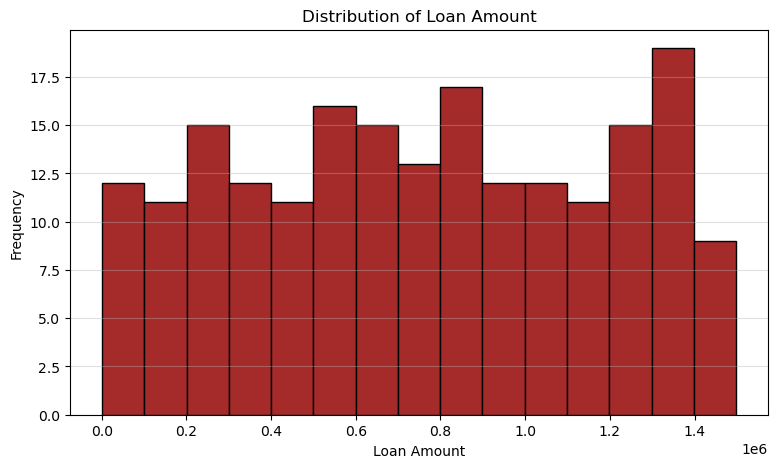

In [33]:
plt.figure(figsize=(9,5))

plt.hist(
    Cus["Loan_Amount"],
    bins=15,
    color="brown",
    edgecolor="black"
)

plt.title("Distribution of Loan Amount")

plt.xlabel("Loan Amount")

plt.ylabel("Frequency")

plt.grid(axis="y", alpha=0.4)

plt.show()

## Skewness
    Skewness measures the asymmetry of a distribution.

    It tells us whether the data is balanced or stretched toward one side.

    Formula
$$
Skewness=\frac{\sum (x_i-\bar{x})^3}{(n-1)s^3}
$$

    Interpretation
        Skewness = 0 → Symmetric
        Skewness > 0 → Right Skewed
        Skewness < 0 → Left Skewed

In [35]:
Cus["Loan_Amount"].skew()

np.float64(-0.024369741480599127)

In [37]:
skew = Cus["Loan_Amount"].skew()

print(f"Skewness : {skew:.3f}")

Skewness : -0.024


In [38]:
if skew > 0:
    print("The distribution is Positively (Right) Skewed.")

elif skew < 0:
    print("The distribution is Negatively (Left) Skewed.")

else:
    print("The distribution is Symmetric.")

The distribution is Negatively (Left) Skewed.


### Frequency Distribution
    A Frequency Distribution is a table that shows how many observations fall into each class interval or category.

    It helps summarize large datasets into an easy-to-read format.

    Formula
        Frequency=Number of observations in a class

In [49]:
bins = [0,200000,400000,600000,800000,1000000,1200000,1500000]

labels = [
    "0-2L",
    "2-4L",
    "4-6L",
    "6-8L",
    "8-10L",
    "10-12L",
    "12-15L"
]

Cus["Loan_Group"] = pd.cut(
    Cus["Loan_Amount"],
    bins=bins,
    labels=labels
)

frequency = Cus["Loan_Group"].value_counts().sort_index()

frequency

Loan_Group
0-2L      23
2-4L      27
4-6L      27
6-8L      28
8-10L     29
10-12L    24
12-15L    42
Name: count, dtype: int64

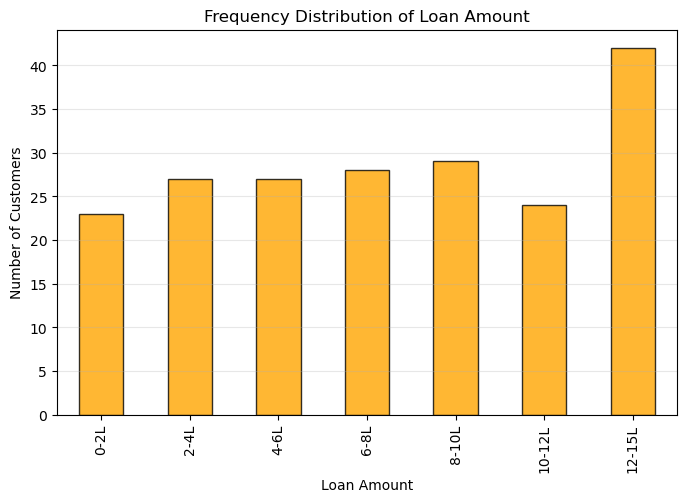

In [53]:
frequency.plot(
    kind="bar",
    figsize=(8,5),
    color="orange",
    edgecolor="black",
    alpha=0.8
)

plt.title("Frequency Distribution of Loan Amount")

plt.xlabel("Loan Amount")

plt.ylabel("Number of Customers")

plt.grid(axis="y", alpha=.3)

plt.show()

### Cumulative Frequency Distribution
    A Cumulative Frequency Distribution shows the running total of frequencies.

    It tells us how many observations are less than or equal to a particular class.

    Formula
        Cumulative Frequency= ∑ Previous Frequencies

In [54]:
cum_freq = frequency.cumsum()

cum_freq

Loan_Group
0-2L       23
2-4L       50
4-6L       77
6-8L      105
8-10L     134
10-12L    158
12-15L    200
Name: count, dtype: int64

In [55]:
freq_table = pd.DataFrame({

    "Frequency": frequency,

    "Cumulative Frequency": frequency.cumsum()

})

freq_table

,Frequency,Cumulative Frequency
Loan_Group,,
0-2L,23,23
2-4L,27,50
4-6L,27,77
6-8L,28,105
8-10L,29,134
10-12L,24,158
12-15L,42,200


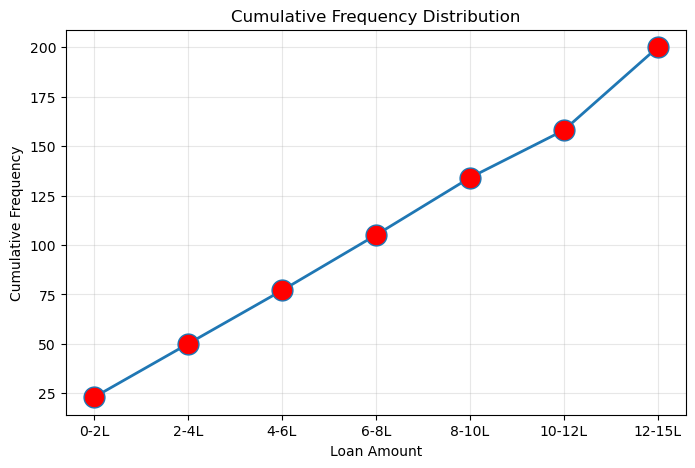

In [59]:
plt.figure(figsize=(8,5))

plt.plot(
    freq_table.index,
    freq_table["Cumulative Frequency"],
    marker="o",
    ms=15,
    mfc='red',
    linewidth=2
)

plt.title("Cumulative Frequency Distribution")

plt.xlabel("Loan Amount")

plt.ylabel("Cumulative Frequency")

plt.grid(alpha=.3)

plt.show()

### Left(Negative) Skewed Distribution

#### Mean < Median < Mode

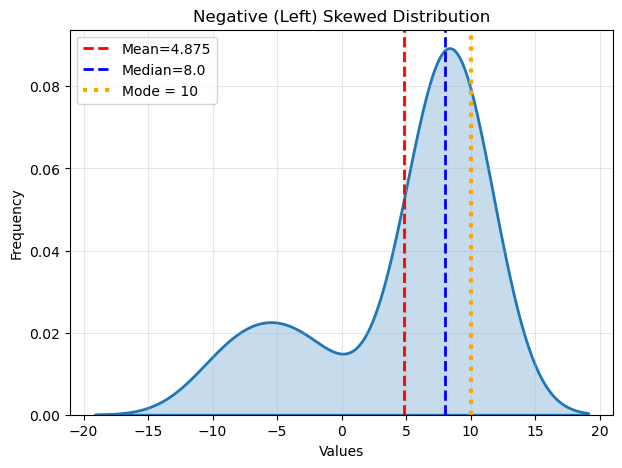

In [128]:


left_skewed = np.array([
-10,-9,-8,-7,-6,-5,-4,-3,-2,-1,
6,6,6,6,
7,7,7,7,7,
8,8,8,8,8,8,
9,9,9,9,9,9,9,
10,10,10,10,10,10,10,10
])

plt.figure(figsize=(7,5))

sns.kdeplot(
    left_skewed,
    fill=True,
    linewidth=2
)
mean = np.mean(left_skewed)
median = np.median(left_skewed)
mode=st.mode(left_skewed)

plt.axvline(mean, color="red", linestyle="--", linewidth=2, label=f"Mean={mean}")
plt.axvline(median, color="blue", linestyle="--", linewidth=2, label=f"Median={median}")

plt.axvline(
    mode,
    color="orange",
    linestyle=":",
    linewidth=3,
    label=f"Mode = {mode}"
)

plt.legend()

plt.title("Negative (Left) Skewed Distribution")

plt.xlabel("Values")

plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()



### Symmetric Distribution 

#### Mean = Median = Mode

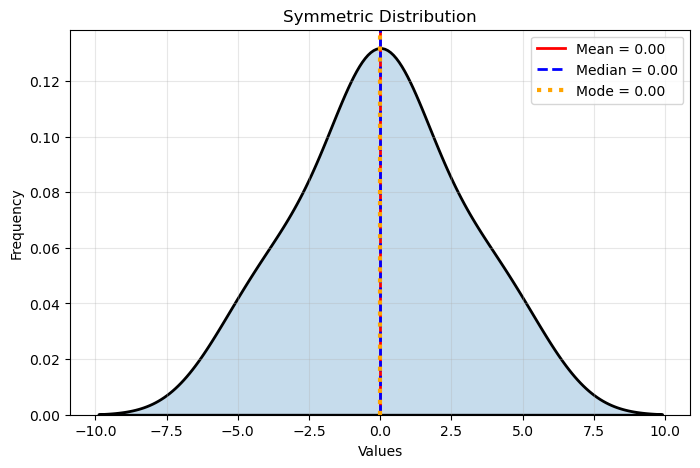

In [131]:

# Symmetric Dataset
symmetric = np.array([
    -5,-4,-3,-2,-1,
     0,0,0,0,0,
     1,2,3,4,5
])

# Calculate Statistics
mean = np.mean(symmetric)
median = np.median(symmetric)
mode = st.mode(symmetric)

plt.figure(figsize=(8,5))

sns.kdeplot(
    symmetric,
    fill=True,
    linewidth=2,
    edgecolor='black'
)

# Mean
plt.axvline(
    mean,
    color="red",
    linestyle="-",
    linewidth=2,
    label=f"Mean = {mean:.2f}"
)

# Median
plt.axvline(
    median,
    color="blue",
    linestyle="--",
    linewidth=2,
    label=f"Median = {median:.2f}"
)

# Mode
plt.axvline(
    mode,
    color="orange",
    linestyle=":",
    linewidth=3,
    label=f"Mode = {mode:.2f}"
)

plt.title("Symmetric Distribution")
plt.xlabel("Values")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.legend()

plt.show()

### Right(Positive) Skewed Distribution

#### Mean > Median > Mode

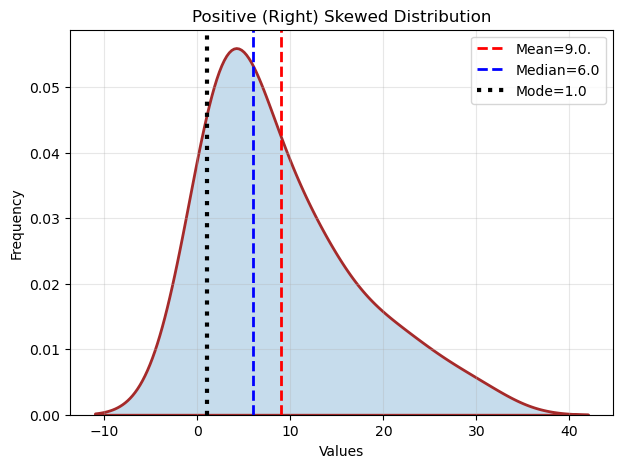

In [134]:
right_skewed = np.array([
1,1,1,2,2,2,3,3,3,
4,4,4,5,5,
6,7,8,9,10,
11,12,13,14,15,
18,20,22,25,30
])

plt.figure(figsize=(7,5))

sns.kdeplot(
    right_skewed,
    fill=True,
    linewidth=2,
    edgecolor='brown'
)

plt.title("Positive (Right) Skewed Distribution")

plt.xlabel("Values")

plt.ylabel("Frequency")

plt.grid(alpha=0.3)

mean = np.mean(right_skewed)
median = np.median(right_skewed)
mode = st.mode(right_skewed)


plt.axvline(mean, color="red", linestyle="--", linewidth=2, label=f"Mean={mean:.1f}.")
plt.axvline(median, color="blue", linestyle="--", linewidth=2, label=f"Median={median}")
plt.axvline(mode,color="black",linestyle=":",linewidth=3,label=f'Mode={mode:.1f}')
plt.legend()

plt.show()

### Kurtosis
    Kurtosis measures how heavy or light the tails of a distribution are compared to a normal distribution.

    It helps identify the presence of extreme values (outliers).

    Formula
$$
Kurtosis=\frac{\sum(x_i-\bar{x})^4}{(n-1)s^4}
$$

    Types
        Leptokurtic → Sharp peak, heavy tails (Kurtosis > 0)
        Mesokurtic → Normal peak (Kurtosis = 0 approximately)
        Platykurtic → Flat peak, light tails (Kurtosis < 0)
    
     Interpretation
        Kurtosis ≈ 0 → Mesokurtic
        Kurtosis > 0 → Leptokurtic
        Kurtosis < 0 → Platykurtic

In [41]:
Cus['Loan_Amount'].kurt()

np.float64(-1.1540519684282822)

In [42]:
kurt = Cus["Loan_Amount"].kurt()

print(f"Kurtosis : {kurt:.3f}")

Kurtosis : -1.154


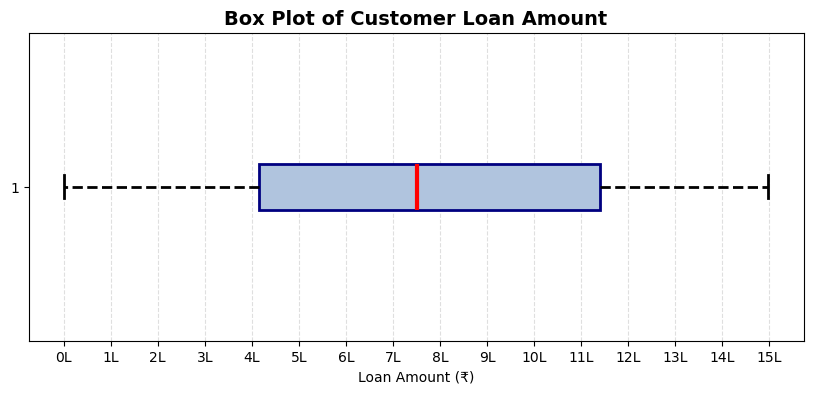

In [139]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.boxplot(
    Cus["Loan_Amount"],
    vert=False,
    patch_artist=True,

    boxprops=dict(
        facecolor="lightsteelblue",
        edgecolor="navy",
        linewidth=2
    ),

    medianprops=dict(
        color="red",
        linewidth=3
    ),

    whiskerprops=dict(
        color="black",
        linewidth=2,
        linestyle="--"
    ),

    capprops=dict(
        color="black",
        linewidth=2
    ),

    flierprops=dict(
        marker="o",
        markerfacecolor="orange",
        markeredgecolor="red",
        markersize=6,
        alpha=0.8
    )
)

plt.title("Box Plot of Customer Loan Amount",
          fontsize=14,
          fontweight="bold")

plt.xlabel("Loan Amount (₹)")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.xticks(
    [0,100000,200000,300000,400000,500000,
     600000,700000,800000,900000,1000000,
     1100000,1200000,1300000,1400000,1500000],

    ["0L","1L","2L","3L","4L","5L",
     "6L","7L","8L","9L","10L",
     "11L","12L","13L","14L","15L"]
)

plt.show()

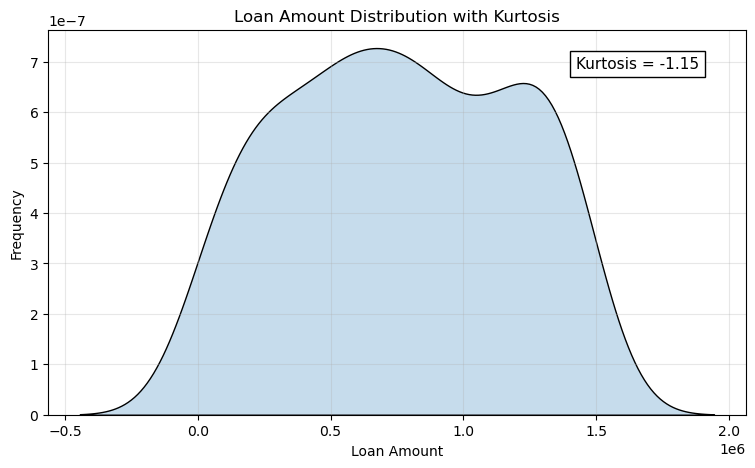

In [153]:

kurt = Cus["Loan_Amount"].kurt()

plt.figure(figsize=(9,5))

sns.kdeplot(
    data=Cus,
    x="Loan_Amount",
    fill=True,
    edgecolor="black"
)

plt.title("Loan Amount Distribution with Kurtosis")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")

plt.text(
    x=Cus["Loan_Amount"].max()*0.95,
    y=plt.ylim()[1]*0.90,
    s=f"Kurtosis = {kurt:.2f}",
    fontsize=11,
    bbox=dict(facecolor="white", edgecolor="black")
)



plt.grid(alpha=0.3)



plt.show()

In [150]:
kurt = Cus["Loan_Amount"].kurt()

print(f"Kurtosis : {kurt:.2f}")

if kurt > 0:
    print("Leptokurtic Distribution")
    print("✔ Sharp peak with heavy tails.")
    print("✔ More extreme values (outliers).")

elif kurt < 0:
    print("Platykurtic Distribution")
    print("✔ Flatter peak with lighter tails.")
    print("✔ Fewer extreme values (outliers).")

else:
    print("Mesokurtic Distribution")
    print("✔ Similar to a normal distribution.")

Kurtosis : -1.15
Platykurtic Distribution
✔ Flatter peak with lighter tails.
✔ Fewer extreme values (outliers).
